# Lab Exercise 3 : Student Survey: Simple Linear Regression using Scikit Learn, OLS, and Parameter Saving

**Name:** Reno Reji Matthew
**Registration Number:** 2547145

---
## Part A: Data Collection and Preprocessing

### Step 1: Import Libraries and Load the Dataset

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_excel("Department Awareness Survey (Responses).xlsx")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (54, 15)


### Step 2: Display the First 5 Rows

In [39]:
df.head(5)

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### Step 3: Check Dataset Dimensions

In [40]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nDataset dimensions: {df.shape}")

Number of rows: 54
Number of columns: 15

Dataset dimensions: (54, 15)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype         
---  ------                                                                                      --------------  -----         
 0   Timestamp                                                                                   54 non-null     datetime64[ns]
 1   Registration Number                                                                         54 non-null     object        
 2   Email                                                                                       54 non-null     object        
 3   Job role that you are interested in
                                                        54 non-null     object        
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null     object        
 

### Step 4: Identify Missing Values

In [42]:
# Strip whitespace from column names for easier access
df.columns = df.columns.str.strip()

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your

### Step 5: Remove or Handle Null Values

In [43]:
# Select only the relevant columns for our regression analysis
# CIA %, GPA, and Attendance %
relevant_cols = ['your CIA % of last semester', 'your GPA of last semester', 
                 'Your maximum attendance % till last semester']

df_reg = df[relevant_cols].copy()
df_reg.columns = ['CIA_Percentage', 'GPA', 'Attendance_Percentage']

print("Before cleaning:")
print(f"Shape: {df_reg.shape}")
print(f"\nUnique values in CIA_Percentage:")
print(sorted(df_reg['CIA_Percentage'].astype(str).unique()))
print(f"\nUnique values in GPA:")
print(sorted(df_reg['GPA'].astype(str).unique()))
print(f"\nUnique values in Attendance_Percentage:")
print(sorted(df_reg['Attendance_Percentage'].astype(str).unique()))

Before cleaning:
Shape: (54, 3)

Unique values in CIA_Percentage:
['-', '0.63', '0.7', '0.7111', '0.75', '0.77', '0.8', '0.88', '3.45', '4', '60', '64.67', '64.78', '66', '67', '68', '70', '70.32', '71', '71.5', '72', '75', '76', '77', '78', '79.33', '80', '83', '84', '85', '86', '89']

Unique values in GPA:
['10', '2.9', '2.93', '3', '3.11', '3.2', '3.24', '3.27', '3.29', '3.3', '3.37', '3.4', '3.46', '3.48', '3.5', '3.51', '3.6', '3.64', '3.67', '3.7', '3.74', '3.75', '3.77', '3.8', '3.86', '3.89', '4', '7.8', '90', 'na']

Unique values in Attendance_Percentage:
['0.87', '0.9', '0.9425', '0.97', '0.98', '0.986', '0.99', '100', '85', '86', '87', '88', '89', '90', '91', '92', '92.08', '92.83', '93', '94', '95', '96', '97', '97.99', '98', '98.03', '98.71', '99', '99.34', 'Option 1']


### Step 6: Convert Required Columns into Numerical Datatype

In [44]:
# Convert to numeric, coercing errors to NaN
df_reg['CIA_Percentage'] = pd.to_numeric(df_reg['CIA_Percentage'], errors='coerce')
df_reg['GPA'] = pd.to_numeric(df_reg['GPA'], errors='coerce')
df_reg['Attendance_Percentage'] = pd.to_numeric(df_reg['Attendance_Percentage'], errors='coerce')

# Handle values entered as decimals
df_reg.loc[df_reg['CIA_Percentage'] < 1, 'CIA_Percentage'] = df_reg.loc[df_reg['CIA_Percentage'] < 1, 'CIA_Percentage'] * 100
df_reg.loc[df_reg['Attendance_Percentage'] < 1, 'Attendance_Percentage'] = df_reg.loc[df_reg['Attendance_Percentage'] < 1, 'Attendance_Percentage'] * 100

# Handle outliers using IQR Method
for col in ['CIA_Percentage', 'GPA', 'Attendance_Percentage']:
    Q1 = df_reg[col].quantile(0.25)
    Q3 = df_reg[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # We will replace outliers with NaN first, then impute
    df_reg.loc[(df_reg[col] < lower_bound) | (df_reg[col] > upper_bound), col] = np.nan

print("After conversion and IQR outlier removal:")
print(df_reg.dtypes)
print(f"\nNull values after conversion:")
print(df_reg.isnull().sum())


After conversion and IQR outlier removal:
CIA_Percentage           float64
GPA                      float64
Attendance_Percentage    float64
dtype: object

Null values after conversion:
CIA_Percentage           3
GPA                      4
Attendance_Percentage    6
dtype: int64


In [45]:
# Updated EDA: Fill missing values with mean (Mean Imputation)
df_reg['CIA_Percentage'] = df_reg['CIA_Percentage'].fillna(df_reg['CIA_Percentage'].mean())
df_reg['GPA'] = df_reg['GPA'].fillna(df_reg['GPA'].mean())
df_reg['Attendance_Percentage'] = df_reg['Attendance_Percentage'].fillna(df_reg['Attendance_Percentage'].mean())

print(f"After Mean Imputation:")
print(f"Shape: {df_reg.shape}")
print(f"Null values: {df_reg.isnull().sum().sum()}")
print(f"Duplicate rows before removal: {df_reg.duplicated().sum()}")


After Mean Imputation:
Shape: (54, 3)
Null values: 0
Duplicate rows before removal: 1


### Step 7: Remove Duplicate Records

In [46]:
print(f"Duplicate rows before removal: {df_reg.duplicated().sum()}")
df_reg = df_reg.drop_duplicates()
df_reg = df_reg.reset_index(drop=True)
print(f"Duplicate rows after removal: {df_reg.duplicated().sum()}")
print(f"Final shape: {df_reg.shape}")

Duplicate rows before removal: 1
Duplicate rows after removal: 0
Final shape: (53, 3)


### Step 8: Generate Statistical Summary

In [47]:
df_reg.describe()

,CIA_Percentage,GPA,Attendance_Percentage
count,53.000000,53.000000,53.000000
mean,74.129612,3.476362,93.236958
std,6.425204,0.261208,4.489113
min,60.000000,2.900000,85.000000
25%,70.000000,3.370000,90.000000
50%,72.000000,3.476800,93.121458
75%,79.330000,3.600000,97.000000
max,89.000000,4.000000,100.000000


### Step 9: Select Dependent and Independent Variables

**Experiment 1:**
- Independent Variable (X): CIA Percentage
- Dependent Variable (Y): GPA

**Experiment 2:**
- Independent Variable (X): Attendance Percentage  
- Dependent Variable (Y): GPA

In [48]:
# Display the cleaned dataset
print("Cleaned Dataset:")
df_reg

Cleaned Dataset:


,CIA_Percentage,GPA,Attendance_Percentage
0,78.000000,3.2400,93.121458
1,64.780000,3.2000,93.121458
2,80.000000,3.6000,93.121458
3,70.000000,3.2000,92.000000
4,68.000000,3.4000,85.000000
5,70.000000,3.5000,87.000000
6,88.000000,3.7000,93.121458
7,74.053137,3.4768,90.000000
8,70.000000,3.4000,89.000000
9,83.000000,3.8900,98.000000


In [49]:
# Save the cleaned dataset as CSV
df_reg.to_csv('cleaned_survey_data.csv', index=False)
print("Cleaned dataset saved as 'cleaned_survey_data.csv'")

Cleaned dataset saved as 'cleaned_survey_data.csv'


---
## Experiment 1: CIA Percentage → GPA

### Part B: Simple Linear Regression using Scikit-learn

### Step 1: Split Dataset into Training and Testing Sets

In [50]:
# Experiment 1: CIA Percentage (X) vs GPA (Y)
X1 = df_reg[['CIA_Percentage']].values
Y1 = df_reg['GPA'].values

# Split into training (80%) and testing (20%) sets
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=42)

print(f"Training set size: {X1_train.shape[0]}")
print(f"Testing set size: {X1_test.shape[0]}")

Training set size: 42
Testing set size: 11


### Step 2: Train the Model using Scikit-learn LinearRegression

In [51]:
# Create and train the model
model1_sklearn = LinearRegression()
model1_sklearn.fit(X1_train, Y1_train)

print("Model trained successfully!")

Model trained successfully!


### Step 3: Obtain Slope and Intercept

In [52]:
slope1_sklearn = model1_sklearn.coef_[0]
intercept1_sklearn = model1_sklearn.intercept_

print(f"Scikit-learn Results (CIA % → GPA):")
print(f"  Slope (m):     {slope1_sklearn:.6f}")
print(f"  Intercept (b): {intercept1_sklearn:.6f}")
print(f"\n  Regression Equation: GPA = {slope1_sklearn:.6f} * CIA_Percentage + {intercept1_sklearn:.6f}")

Scikit-learn Results (CIA % → GPA):
  Slope (m):     0.013687
  Intercept (b): 2.464925

  Regression Equation: GPA = 0.013687 * CIA_Percentage + 2.464925


### Step 4: Predict Output Values

In [53]:
# Predict on test set
Y1_pred_sklearn = model1_sklearn.predict(X1_test)

print("Predictions from Scikit-learn (CIA % → GPA):")
results1_sklearn = pd.DataFrame({
    'CIA_Percentage': X1_test.flatten(),
    'Actual_GPA': Y1_test,
    'Predicted_GPA (Sklearn)': Y1_pred_sklearn.round(4)
})
print(results1_sklearn.to_string(index=False))

Predictions from Scikit-learn (CIA % → GPA):
 CIA_Percentage  Actual_GPA  Predicted_GPA (Sklearn)
          78.00        3.75                   3.5325
          80.00        3.80                   3.5599
          71.50        3.46                   3.4435
          70.00        3.48                   3.4230
          75.00        3.00                   3.4914
          70.00        3.50                   3.4230
          66.00        2.90                   3.3682
          79.33        3.80                   3.5507
          70.00        3.20                   3.4230
          75.00        3.60                   3.4914
          64.67        3.40                   3.3500


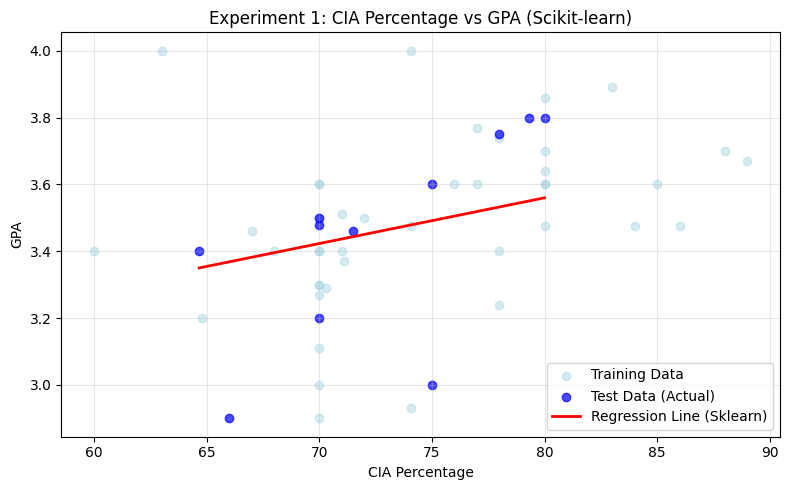

In [54]:
# Visualize Experiment 1 - Scikit-learn
plt.figure(figsize=(8, 5))
# Plot training data as light dots
plt.scatter(X1_train, Y1_train, color="lightblue", label="Training Data", alpha=0.5)
# Plot test data as solid dots
plt.scatter(X1_test, Y1_test, color="blue", label="Test Data (Actual)", alpha=0.7)
# Sort test data for a clean regression line
sort_idx = X1_test.flatten().argsort()
X1_sorted = X1_test.flatten()[sort_idx]
Y1_sorted = Y1_pred_sklearn[sort_idx]
plt.plot(X1_sorted, Y1_sorted, color="red", linewidth=2, label="Regression Line (Sklearn)")
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Experiment 1: CIA Percentage vs GPA (Scikit-learn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part C: Manual Computation using Ordinary Least Squares (OLS)

**OLS Formulas:**

**Slope equation m:**

$$m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

**Intercept equation b:**

$$b = \bar{y} - m \cdot \bar{x}$$

**Final regression equation:**

$$\hat{y} = m \cdot x + b$$

**Where:**
- $x_i$ = individual input value
- $y_i$ = individual output value
- $\bar{x}$ = mean of x values
- $\bar{y}$ = mean of y values
- $m$ = slope
- $b$ = intercept
- $\hat{y}$ = predicted value

In [55]:
### Create Custom Linear Regression Class
class LR:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        # Manual OLS Computation using the deviation-from-mean OLS formula
        num = 0
        den = 0
        x_mean = X_train.mean()
        y_mean = y_train.mean()
        
        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - x_mean) * (y_train[i] - y_mean))
            den = den + ((X_train[i] - x_mean) * (X_train[i] - x_mean))
            
        self.m = num / den
        self.b = y_mean - (self.m * x_mean)
        
        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):
        return self.m * X_test + self.b


In [56]:
# Manual OLS Computation for Experiment 1 using Custom LR Class
lr1 = LR()
x_train = X1_train.flatten()
y_train = Y1_train

print("Manual OLS Results (CIA % → GPA):\n")
lr1.fit(x_train, y_train)

slope1_manual = lr1.m
intercept1_manual = lr1.b
print(f"\nRegression Equation: GPA = {slope1_manual:.6f} * CIA_Percentage + {intercept1_manual:.6f}")


Manual OLS Results (CIA % → GPA):

Slope (m) = 0.013686571964781354
Intercept (b) = 2.464925246226116

Regression Equation: GPA = 0.013687 * CIA_Percentage + 2.464925


In [57]:
# Predict using custom LR class
Y1_pred_manual = lr1.predict(X1_test.flatten())

print("Predictions from Custom LR (CIA % → GPA):\n")
results1_manual = pd.DataFrame({
    "CIA_Percentage": X1_test.flatten(),
    "Actual_GPA": Y1_test,
    "Predicted_GPA (Custom LR)": Y1_pred_manual.round(4)
})
print(results1_manual.to_string(index=False))


Predictions from Custom LR (CIA % → GPA):

 CIA_Percentage  Actual_GPA  Predicted_GPA (Custom LR)
          78.00        3.75                     3.5325
          80.00        3.80                     3.5599
          71.50        3.46                     3.4435
          70.00        3.48                     3.4230
          75.00        3.00                     3.4914
          70.00        3.50                     3.4230
          66.00        2.90                     3.3682
          79.33        3.80                     3.5507
          70.00        3.20                     3.4230
          75.00        3.60                     3.4914
          64.67        3.40                     3.3500


### Comparison: Scikit-learn vs Manual OLS (Experiment 1)

In [58]:
# Compare predictions from both methods
comparison1 = pd.DataFrame({
    'CIA_Percentage': X1_test.flatten(),
    'Actual_GPA': Y1_test,
    'Sklearn_Prediction': Y1_pred_sklearn.round(6),
    'Manual_OLS_Prediction': Y1_pred_manual.round(6),
    'Difference': np.abs(Y1_pred_sklearn - Y1_pred_manual).round(10)
})

print("=" * 90)
print("COMPARISON TABLE: Scikit-learn vs Manual OLS (Experiment 1: CIA % → GPA)")
print("=" * 90)
print(comparison1.to_string(index=False))
print(f"\nMaximum difference between methods: {comparison1['Difference'].max():.2e}")
print(f"Mean difference between methods: {comparison1['Difference'].mean():.2e}")

COMPARISON TABLE: Scikit-learn vs Manual OLS (Experiment 1: CIA % → GPA)
 CIA_Percentage  Actual_GPA  Sklearn_Prediction  Manual_OLS_Prediction  Difference
          78.00        3.75            3.532478               3.532478         0.0
          80.00        3.80            3.559851               3.559851         0.0
          71.50        3.46            3.443515               3.443515         0.0
          70.00        3.48            3.422985               3.422985         0.0
          75.00        3.00            3.491418               3.491418         0.0
          70.00        3.50            3.422985               3.422985         0.0
          66.00        2.90            3.368239               3.368239         0.0
          79.33        3.80            3.550681               3.550681         0.0
          70.00        3.20            3.422985               3.422985         0.0
          75.00        3.60            3.491418               3.491418         0.0
          64.6

In [59]:
# Compare parameters
print("\nParameter Comparison (Experiment 1: CIA % → GPA):")
print(f"{'Parameter':<15} {'Scikit-learn':<20} {'Manual OLS':<20} {'Difference':<20}")
print("-" * 75)
print(f"{'Slope':<15} {slope1_sklearn:<20.10f} {slope1_manual:<20.10f} {abs(slope1_sklearn - slope1_manual):<20.2e}")
print(f"{'Intercept':<15} {intercept1_sklearn:<20.10f} {intercept1_manual:<20.10f} {abs(intercept1_sklearn - intercept1_manual):<20.2e}")


Parameter Comparison (Experiment 1: CIA % → GPA):
Parameter       Scikit-learn         Manual OLS           Difference          
---------------------------------------------------------------------------
Slope           0.0136865720         0.0136865720         6.94e-18            
Intercept       2.4649252462         2.4649252462         8.88e-16            


---
## Experiment 2: Attendance Percentage → GPA

### Part B: Simple Linear Regression using Scikit-learn

### Step 1: Split Dataset into Training and Testing Sets

In [60]:
# Experiment 2: Attendance Percentage (X) vs GPA (Y)
X2 = df_reg[['Attendance_Percentage']].values
Y2 = df_reg['GPA'].values

# Split into training (80%) and testing (20%) sets
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=42)

print(f"Training set size: {X2_train.shape[0]}")
print(f"Testing set size: {X2_test.shape[0]}")

Training set size: 42
Testing set size: 11


### Step 2: Train the Model using Scikit-learn LinearRegression

In [61]:
# Create and train the model
model2_sklearn = LinearRegression()
model2_sklearn.fit(X2_train, Y2_train)

print("Model trained successfully!")

Model trained successfully!


### Step 3: Obtain Slope and Intercept

In [62]:
slope2_sklearn = model2_sklearn.coef_[0]
intercept2_sklearn = model2_sklearn.intercept_

print(f"Scikit-learn Results (Attendance % → GPA):")
print(f"  Slope (m):     {slope2_sklearn:.6f}")
print(f"  Intercept (b): {intercept2_sklearn:.6f}")
print(f"\n  Regression Equation: GPA = {slope2_sklearn:.6f} * Attendance_Percentage + {intercept2_sklearn:.6f}")

Scikit-learn Results (Attendance % → GPA):
  Slope (m):     0.017950
  Intercept (b): 1.815976

  Regression Equation: GPA = 0.017950 * Attendance_Percentage + 1.815976


### Step 4: Predict Output Values

In [63]:
# Predict on test set
Y2_pred_sklearn = model2_sklearn.predict(X2_test)

print("Predictions from Scikit-learn (Attendance % → GPA):")
results2_sklearn = pd.DataFrame({
    'Attendance_Percentage': X2_test.flatten(),
    'Actual_GPA': Y2_test,
    'Predicted_GPA (Sklearn)': Y2_pred_sklearn.round(4)
})
print(results2_sklearn.to_string(index=False))

Predictions from Scikit-learn (Attendance % → GPA):
 Attendance_Percentage  Actual_GPA  Predicted_GPA (Sklearn)
                  95.0        3.75                   3.5212
                  98.0        3.80                   3.5751
                  98.0        3.46                   3.5751
                  97.0        3.48                   3.5571
                  90.0        3.00                   3.4315
                  87.0        3.50                   3.3776
                  91.0        2.90                   3.4494
                 100.0        3.80                   3.6110
                  92.0        3.20                   3.4674
                  94.0        3.60                   3.5033
                  95.0        3.40                   3.5212


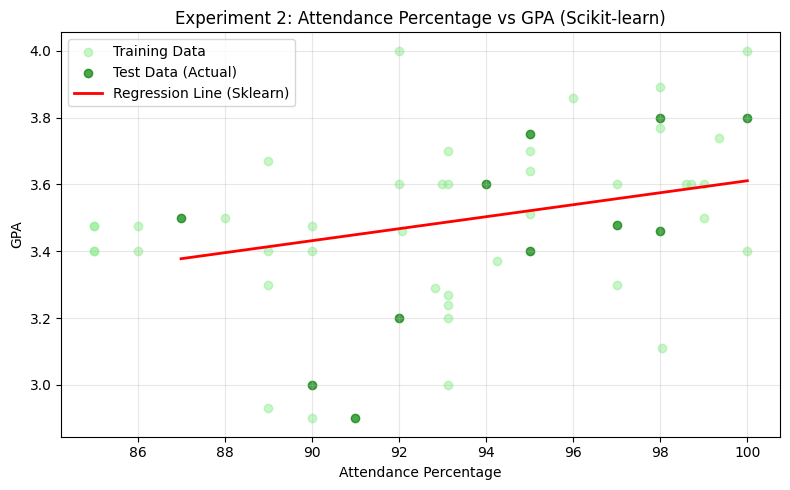

In [64]:
# Visualize Experiment 2 - Scikit-learn
plt.figure(figsize=(8, 5))
# Plot training data as light dots
plt.scatter(X2_train, Y2_train, color="lightgreen", label="Training Data", alpha=0.5)
# Plot test data as solid dots
plt.scatter(X2_test, Y2_test, color="green", label="Test Data (Actual)", alpha=0.7)
# Sort test data for a clean regression line
sort_idx2 = X2_test.flatten().argsort()
X2_sorted = X2_test.flatten()[sort_idx2]
Y2_sorted = Y2_pred_sklearn[sort_idx2]
plt.plot(X2_sorted, Y2_sorted, color="red", linewidth=2, label="Regression Line (Sklearn)")
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Experiment 2: Attendance Percentage vs GPA (Scikit-learn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part C: Manual Computation using Ordinary Least Squares (OLS)

**OLS Formulas:**

**Slope equation m:**

$$m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

**Intercept equation b:**

$$b = \bar{y} - m \cdot \bar{x}$$

In [65]:
# Manual OLS Computation for Experiment 2 using Custom LR Class
lr2 = LR()
x_train2 = X2_train.flatten()
y_train2 = Y2_train

print("Manual OLS Results (Attendance % → GPA):\n")
lr2.fit(x_train2, y_train2)

slope2_manual = lr2.m
intercept2_manual = lr2.b
print(f"\nRegression Equation: GPA = {slope2_manual:.6f} * Attendance_Percentage + {intercept2_manual:.6f}")


Manual OLS Results (Attendance % → GPA):

Slope (m) = 0.017949845055949307
Intercept (b) = 1.8159756053725926

Regression Equation: GPA = 0.017950 * Attendance_Percentage + 1.815976


In [66]:
# Predict using custom LR class
Y2_pred_manual = lr2.predict(X2_test.flatten())

print("Predictions from Custom LR (Attendance % → GPA):\n")
results2_manual = pd.DataFrame({
    "Attendance_Percentage": X2_test.flatten(),
    "Actual_GPA": Y2_test,
    "Predicted_GPA (Custom LR)": Y2_pred_manual.round(4)
})
print(results2_manual.to_string(index=False))


Predictions from Custom LR (Attendance % → GPA):

 Attendance_Percentage  Actual_GPA  Predicted_GPA (Custom LR)
                  95.0        3.75                     3.5212
                  98.0        3.80                     3.5751
                  98.0        3.46                     3.5751
                  97.0        3.48                     3.5571
                  90.0        3.00                     3.4315
                  87.0        3.50                     3.3776
                  91.0        2.90                     3.4494
                 100.0        3.80                     3.6110
                  92.0        3.20                     3.4674
                  94.0        3.60                     3.5033
                  95.0        3.40                     3.5212


### Comparison: Scikit-learn vs Manual OLS (Experiment 2)

In [67]:
# Compare predictions from both methods
comparison2 = pd.DataFrame({
    'Attendance_Percentage': X2_test.flatten(),
    'Actual_GPA': Y2_test,
    'Sklearn_Prediction': Y2_pred_sklearn.round(6),
    'Manual_OLS_Prediction': Y2_pred_manual.round(6),
    'Difference': np.abs(Y2_pred_sklearn - Y2_pred_manual).round(10)
})

print("=" * 95)
print("COMPARISON TABLE: Scikit-learn vs Manual OLS (Experiment 2: Attendance % → GPA)")
print("=" * 95)
print(comparison2.to_string(index=False))
print(f"\nMaximum difference between methods: {comparison2['Difference'].max():.2e}")
print(f"Mean difference between methods: {comparison2['Difference'].mean():.2e}")

COMPARISON TABLE: Scikit-learn vs Manual OLS (Experiment 2: Attendance % → GPA)
 Attendance_Percentage  Actual_GPA  Sklearn_Prediction  Manual_OLS_Prediction  Difference
                  95.0        3.75            3.521211               3.521211         0.0
                  98.0        3.80            3.575060               3.575060         0.0
                  98.0        3.46            3.575060               3.575060         0.0
                  97.0        3.48            3.557111               3.557111         0.0
                  90.0        3.00            3.431462               3.431462         0.0
                  87.0        3.50            3.377612               3.377612         0.0
                  91.0        2.90            3.449412               3.449412         0.0
                 100.0        3.80            3.610960               3.610960         0.0
                  92.0        3.20            3.467361               3.467361         0.0
                  94

In [68]:
# Compare parameters
print("\nParameter Comparison (Experiment 2: Attendance % → GPA):")
print(f"{'Parameter':<15} {'Scikit-learn':<20} {'Manual OLS':<20} {'Difference':<20}")
print("-" * 75)
print(f"{'Slope':<15} {slope2_sklearn:<20.10f} {slope2_manual:<20.10f} {abs(slope2_sklearn - slope2_manual):<20.2e}")
print(f"{'Intercept':<15} {intercept2_sklearn:<20.10f} {intercept2_manual:<20.10f} {abs(intercept2_sklearn - intercept2_manual):<20.2e}")


Parameter Comparison (Experiment 2: Attendance % → GPA):
Parameter       Scikit-learn         Manual OLS           Difference          
---------------------------------------------------------------------------
Slope           0.0179498451         0.0179498451         1.39e-17            
Intercept       1.8159756054         1.8159756054         1.33e-15            


---
## Parameter Saving Task: Save Model Parameters using Pickle

### 1. Saving Parameters into Pickle File

In [69]:
# Save learned parameters for both experiments
model_parameters = {
    'Experiment_1_CIA_to_GPA': {
        'slope': slope1_sklearn,
        'intercept': intercept1_sklearn
    },
    'Experiment_2_Attendance_to_GPA': {
        'slope': slope2_sklearn,
        'intercept': intercept2_sklearn
    }
}

# Save to pickle file
with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(model_parameters, f)

print("Model parameters saved to 'linear_regression_weights.pkl'")
print(f"\nSaved parameters:")
for exp_name, params in model_parameters.items():
    print(f"  {exp_name}:")
    print(f"    Slope:     {params['slope']:.6f}")
    print(f"    Intercept: {params['intercept']:.6f}")

Model parameters saved to 'linear_regression_weights.pkl'

Saved parameters:
  Experiment_1_CIA_to_GPA:
    Slope:     0.013687
    Intercept: 2.464925
  Experiment_2_Attendance_to_GPA:
    Slope:     0.017950
    Intercept: 1.815976


### 2. Loading the Pickle File

In [70]:
# Load parameters from pickle file
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_parameters = pickle.load(f)

print("Parameters loaded from 'linear_regression_weights.pkl':")
for exp_name, params in loaded_parameters.items():
    print(f"  {exp_name}:")
    print(f"    Slope:     {params['slope']:.6f}")
    print(f"    Intercept: {params['intercept']:.6f}")

Parameters loaded from 'linear_regression_weights.pkl':
  Experiment_1_CIA_to_GPA:
    Slope:     0.013687
    Intercept: 2.464925
  Experiment_2_Attendance_to_GPA:
    Slope:     0.017950
    Intercept: 1.815976


### 3. Using Loaded Parameters for Prediction

In [71]:
# Use loaded parameters for prediction
# Example: Predict GPA for CIA = 75% and Attendance = 90%

test_cia = 75
test_attendance = 90

# Experiment 1: CIA → GPA
loaded_slope1 = loaded_parameters['Experiment_1_CIA_to_GPA']['slope']
loaded_intercept1 = loaded_parameters['Experiment_1_CIA_to_GPA']['intercept']
predicted_gpa_from_cia = loaded_slope1 * test_cia + loaded_intercept1

# Experiment 2: Attendance → GPA
loaded_slope2 = loaded_parameters['Experiment_2_Attendance_to_GPA']['slope']
loaded_intercept2 = loaded_parameters['Experiment_2_Attendance_to_GPA']['intercept']
predicted_gpa_from_attendance = loaded_slope2 * test_attendance + loaded_intercept2

print(f"Predictions using loaded model parameters:")
print(f"\n  For CIA Percentage = {test_cia}%:")
print(f"    Predicted GPA = {loaded_slope1:.6f} × {test_cia} + {loaded_intercept1:.6f} = {predicted_gpa_from_cia:.4f}")
print(f"\n  For Attendance Percentage = {test_attendance}%:")
print(f"    Predicted GPA = {loaded_slope2:.6f} × {test_attendance} + {loaded_intercept2:.6f} = {predicted_gpa_from_attendance:.4f}")

Predictions using loaded model parameters:

  For CIA Percentage = 75%:
    Predicted GPA = 0.013687 × 75 + 2.464925 = 3.4914

  For Attendance Percentage = 90%:
    Predicted GPA = 0.017950 × 90 + 1.815976 = 3.4315


In [72]:
from sklearn.metrics import r2_score

r2_1 = r2_score(Y1_test, Y1_pred_sklearn)
r2_2 = r2_score(Y2_test, Y2_pred_sklearn)

print("=" * 60)
print("R-SQUARED (R²) EVALUATION")
print("=" * 60)
print(f"Experiment 1 (CIA % -> GPA) R² Score: {r2_1:.4f}")
print(f"Experiment 2 (Attendance % -> GPA) R² Score: {r2_2:.4f}")
print("=" * 60)


R-SQUARED (R²) EVALUATION
Experiment 1 (CIA % -> GPA) R² Score: 0.2464
Experiment 2 (Attendance % -> GPA) R² Score: 0.1873
